# Am-Be source in paraffin cylinder model

This cleaned version of Notebook 1 defines and documents the common OpenMC base model used by the later notebooks.

The notebook does **not** redefine the full geometry inside the notebook. Instead, the geometry, materials, source spectrum and base tallies are imported from the shared module:

`ambe_base_model.py`

This avoids the old problem where Notebook 1 contained duplicated geometry definitions and could therefore overwrite or conflict with itself when cells were run out of order.

The notebook produces and saves:

1. Am-Be neutron source spectrum figure and metadata.
2. Am-Be gamma-line source figure and metadata.
3. Base geometry/material/tally summary tables.
4. Geometry render figures without tally points.
5. Geometry render figures with base tally points.
6. Final metadata table documenting source strength, geometry placement and output paths.

## 1) Setup and imports

This cell imports dependencies, reloads the shared base-model module, and creates the output folders used by this notebook.

In [56]:
import os
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmc

try:
    import ambe_base_model
    importlib.reload(ambe_base_model)
except ImportError as error:
    raise ImportError(
        "Could not import 'ambe_base_model.py'. Make sure it is in the same folder as this notebook."
    ) from error

BASE_DIR = Path.cwd().resolve()
OUTPUT_DIR = BASE_DIR / "base_model_outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
XML_DIR = OUTPUT_DIR / "xml"

for folder in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, XML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

print("Notebook 1 setup completed.")
print(f"Working directory: {BASE_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")
print(f"OpenMC version:    {openmc.__version__}")
print(f"ALPHANSO available in module: {getattr(ambe_base_model, 'HAS_ALPHANSO', 'unknown')}")
print(f"OPENMC_CROSS_SECTIONS: {os.environ.get('OPENMC_CROSS_SECTIONS', '<not set>')}")

Notebook 1 setup completed.
Working directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output directory:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs
OpenMC version:    0.15.3
ALPHANSO available in module: True
OPENMC_CROSS_SECTIONS: /root/nndc_hdf5/cross_sections.xml


## 2) Am-Be source spectrum and gamma-line model

The neutron spectrum is obtained from `ambe_base_model.py`. If ALPHANSO is available, the ALPHANSO spectrum is used; otherwise the module fallback spectrum is used.

The gamma source is represented by discrete prompt gamma lines from the Am-Be reaction. In this model the dominant line is the hard gamma line near $4.44\,\mathrm{MeV}$ from de-excitation of excited carbon-12:

$$
{}^{12}\mathrm{C}^{*} \rightarrow {}^{12}\mathrm{C} + \gamma .
$$

The gamma-line model is a source description before transport through the paraffin, cabinet, lead shielding and air.

Running ALPHANSO calculation...
Total (alpha, n) yield: 4.268e+06 neutrons/s/g
energy_edges length: 121
spectrum length: 120
ALPHANSO Am-Be spectrum
Spectrum bins: 120
OpenMC energy points: 120
Energy range: 0.05 to 11.95 MeV
Sum of probabilities: 1.0


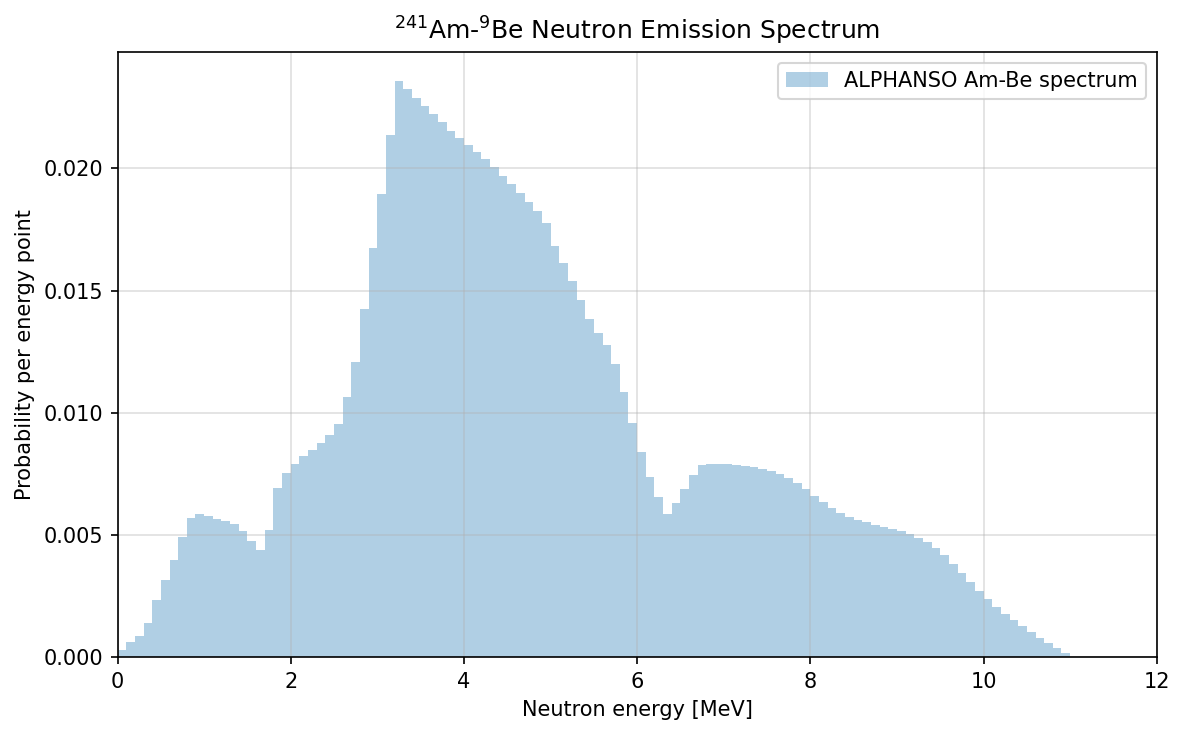

Saved neutron spectrum figure: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/figures/ambe_neutron_emission_spectrum.png
Number of energy points: 120
Energy range: 0.05 to 11.95 MeV
Sum of probabilities: 1.000000


In [57]:
# ============================================================
# Build and save Am-Be neutron energy spectrum
# ============================================================

neutron_energy_dist = ambe_base_model.build_ambe_energy_distribution(
    make_plot=False,
    verbose=True,
)

neutron_energy_ev = np.asarray(neutron_energy_dist.x, dtype=float)
neutron_energy_prob = np.asarray(neutron_energy_dist.p, dtype=float)

neutron_energy_mev = neutron_energy_ev / 1.0e6

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

ax.bar(
    neutron_energy_mev,
    neutron_energy_prob,
    width=np.diff(neutron_energy_mev).mean(),
    align="center",
    alpha=0.35,
    label="ALPHANSO Am-Be spectrum"
)

ax.set_title(r"$^{241}$Am-$^{9}$Be Neutron Emission Spectrum")
ax.set_xlabel("Neutron energy [MeV]")
ax.set_ylabel("Probability per energy point")
ax.grid(alpha=0.4)
ax.set_xlim(0, 12)
ax.legend()

fig.tight_layout()

neutron_spectrum_path = FIGURE_DIR / "ambe_neutron_emission_spectrum.png"
fig.savefig(neutron_spectrum_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved neutron spectrum figure: {neutron_spectrum_path}")
print(f"Number of energy points: {len(neutron_energy_mev)}")
print(f"Energy range: {neutron_energy_mev.min():.2f} to {neutron_energy_mev.max():.2f} MeV")
print(f"Sum of probabilities: {neutron_energy_prob.sum():.6f}")

ALPHANSO gamma emission lines:
  Total gamma yield: 2.783366e+06
  E = 3.2138 MeV, yield = 1.559798e+02, probability = 0.005604 %
  E = 4.4389 MeV, yield = 2.783210e+06, probability = 99.994396 %

Dominant gamma line:
  E = 4.4389 MeV
  probability = 99.994396 %


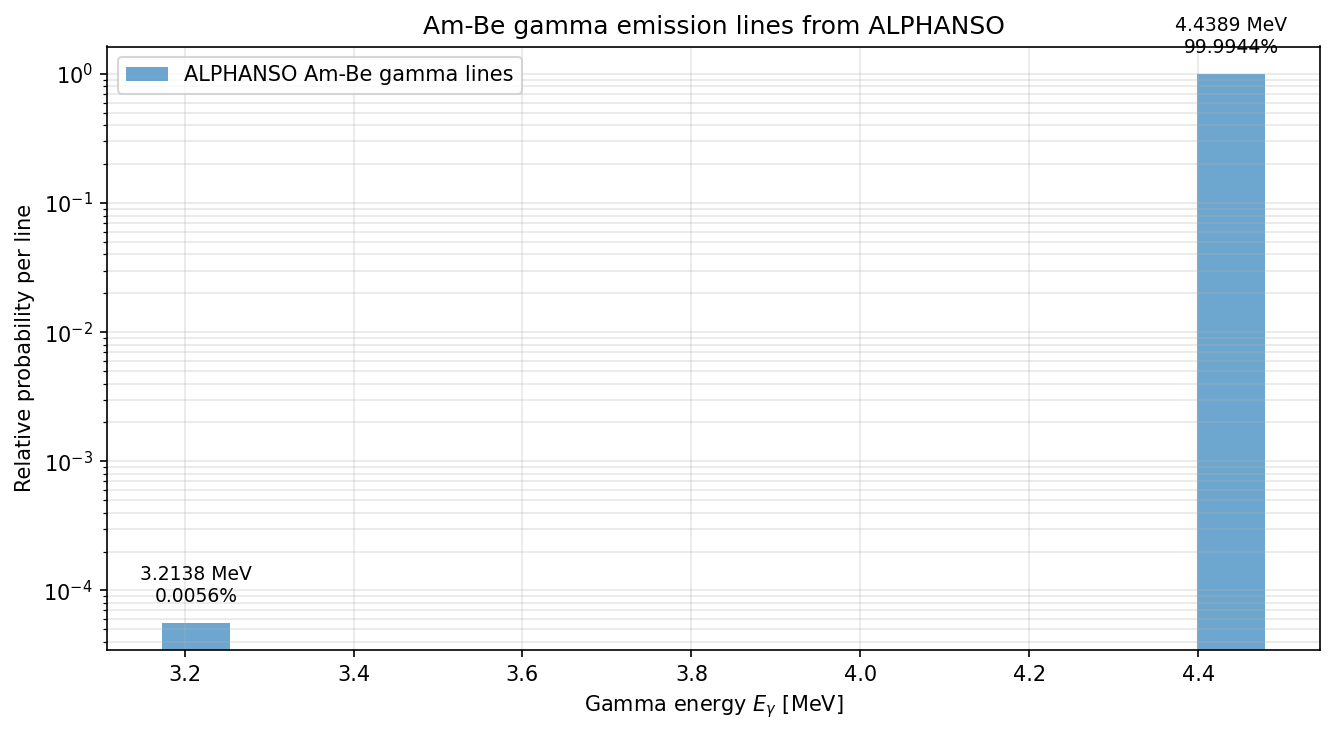

Saved gamma-line table:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/ambe_gamma_lines.csv
Saved gamma-line figure: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/figures/ambe_gamma_emission_lines.png
Total gamma yield: 2.783366e+06
Dominant gamma energy: 4.4389 MeV
Sum of probabilities: 1.000000


,E_gamma_MeV,line_yield,relative_probability,relative_probability_percent
0,3.2138,1.559798e+02,0.000056,0.005604
1,4.4389,2.783210e+06,0.999944,99.994396


In [58]:
# ============================================================
# Build and save Am-Be gamma emission lines
# ============================================================

if not hasattr(ambe_base_model, "build_ambe_gamma_line_distribution"):
    raise AttributeError(
        "The shared module does not contain build_ambe_gamma_line_distribution(). "
        "Update ambe_base_model.py before running this notebook."
    )

gamma_energy_dist, gamma_data = ambe_base_model.build_ambe_gamma_line_distribution(
    make_plot=False,
    verbose=True,
)

gamma_energies_mev = np.asarray(gamma_data["gamma_energies_mev"], dtype=float)
gamma_line_yields = np.asarray(gamma_data["gamma_line_yields"], dtype=float)
gamma_prob = np.asarray(gamma_data["gamma_prob"], dtype=float)

gamma_lines_df = pd.DataFrame({
    "E_gamma_MeV": gamma_energies_mev,
    "line_yield": gamma_line_yields,
    "relative_probability": gamma_prob,
    "relative_probability_percent": 100.0 * gamma_prob,
})

gamma_lines_path = TABLE_DIR / "ambe_gamma_lines.csv"
gamma_lines_df.to_csv(gamma_lines_path, index=False)

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

bar_width = 0.08  # MeV, only for visualization of discrete lines

ax.bar(
    gamma_energies_mev,
    gamma_prob,
    width=bar_width,
    align="center",
    alpha=0.65,
    label="ALPHANSO Am-Be gamma lines"
)

for energy, prob in zip(gamma_energies_mev, gamma_prob):
    ax.text(
        energy,
        prob * 1.35,
        f"{energy:.4f} MeV\n{100.0 * prob:.4f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_yscale("log")
ax.set_title("Am-Be gamma emission lines from ALPHANSO")
ax.set_xlabel(r"Gamma energy $E_\gamma$ [MeV]")
ax.set_ylabel("Relative probability per line")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()

gamma_lines_path_png = FIGURE_DIR / "ambe_gamma_emission_lines.png"
fig.savefig(gamma_lines_path_png, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved gamma-line table:  {gamma_lines_path}")
print(f"Saved gamma-line figure: {gamma_lines_path_png}")
print(f"Total gamma yield: {gamma_data['gamma_yield']:.6e}")
print(f"Dominant gamma energy: {gamma_energies_mev[np.argmax(gamma_prob)]:.4f} MeV")
print(f"Sum of probabilities: {gamma_prob.sum():.6f}")

display(gamma_lines_df)

In [59]:
# Source scaling summary
SOURCE_NEUTRON_EMISSION = getattr(ambe_base_model, "SOURCE_NEUTRON_EMISSION", 1.2e7)

gamma_yield = float(gamma_data.get("gamma_yield", np.nan))
alphanso_results = gamma_data.get("alphanso_results", {})

if isinstance(alphanso_results, dict) and "an_yield" in alphanso_results:
    neutron_yield_for_ratio = float(alphanso_results["an_yield"])
else:
    neutron_yield_for_ratio = np.nan

gamma_per_neutron_ratio = gamma_yield / neutron_yield_for_ratio if np.isfinite(neutron_yield_for_ratio) else np.nan
source_gamma_emission = SOURCE_NEUTRON_EMISSION * gamma_per_neutron_ratio if np.isfinite(gamma_per_neutron_ratio) else np.nan

source_scaling_summary_df = pd.DataFrame([
    {"quantity": "Assumed neutron source emission", "symbol": "S_n", "value": SOURCE_NEUTRON_EMISSION, "unit": "n/s"},
    {"quantity": "ALPHANSO neutron yield", "symbol": "Y_n", "value": neutron_yield_for_ratio, "unit": "ALPHANSO yield units"},
    {"quantity": "ALPHANSO gamma yield", "symbol": "Y_gamma", "value": gamma_yield, "unit": "ALPHANSO yield units"},
    {"quantity": "Estimated gamma/neutron emission ratio", "symbol": "Y_gamma / Y_n", "value": gamma_per_neutron_ratio, "unit": "photons/neutron"},
    {"quantity": "Estimated gamma source emission", "symbol": "S_gamma", "value": source_gamma_emission, "unit": "photons/s"},
])

source_scaling_path = TABLE_DIR / "source_scaling_summary.csv"
source_scaling_summary_df.to_csv(source_scaling_path, index=False)

print("Source scaling summary saved.")
print(source_scaling_path)
display(source_scaling_summary_df)

Source scaling summary saved.
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/source_scaling_summary.csv


,quantity,symbol,value,unit
0,Assumed neutron source emission,S_n,1.200000e+07,n/s
1,ALPHANSO neutron yield,Y_n,4.268302e+06,ALPHANSO yield units
2,ALPHANSO gamma yield,Y_gamma,2.783366e+06,ALPHANSO yield units
3,Estimated gamma/neutron emission ratio,Y_gamma / Y_n,6.521014e-01,photons/neutron
4,Estimated gamma source emission,S_gamma,7.825217e+06,photons/s


## 3) Build shared base geometry and materials

This cell builds the geometry and material model by calling the shared module. The notebook itself does not contain separate geometry definitions, so the later notebooks and this notebook use the same geometry source.

In [60]:
# Build the full base model from the shared module.
# The returned dictionary contains geometry, materials, cells and useful constants.
base = ambe_base_model.build_base_model(
    export_xml=True,
    verbose=True,
)

# Copy important objects into short notebook variables
model = base["model"]
geometry = base["geometry"]
materials = base["materials"]
root = base["root"]
settings = base.get("settings", None)
tallies = base.get("tallies", None)

print()
print("Shared base model built successfully.")
print("materials:", type(materials))
print("geometry :", type(geometry))
print("root     :", type(root))
print("model    :", type(model))
if tallies is not None:
    print("tallies  :", type(tallies), "with", len(tallies), "tallies")

Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           = 0.955 cm
  Source active radius          = 0.675 cm
  Source active height          = 4.300 cm

Materials and geometry built.
Defined cells:
  169: Cabinet wall
  170: Cabinet inner air
  171: Inner paraffin block around source
  172: Outer paraffin moderator
  173: 

In [61]:
# Extract frequently used geometry constants from base
for name in [
    "CABINET_X", "CABINET_Y", "CABINET_Z",
    "CABINET_XMIN", "CABINET_XMAX", "CABINET_YMIN", "CABINET_YMAX", "CABINET_ZMIN", "CABINET_ZMAX", "CABINET_ZCENTER",
    "CABINET_INNER_XMIN", "CABINET_INNER_XMAX", "CABINET_INNER_YMIN", "CABINET_INNER_YMAX", "CABINET_INNER_ZMIN", "CABINET_INNER_ZMAX",
    "PARAFFIN_RADIUS", "PARAFFIN_HEIGHT", "PARAFFIN_ZMIN", "PARAFFIN_ZMAX",
    "PLASTIC_OUTER_RADIUS", "PLASTIC_INNER_RADIUS",
    "SOURCE_OUTER_RADIUS", "SOURCE_HEIGHT", "SOURCE_ZMIN", "SOURCE_ZMAX",
    "SOURCE_ACTIVE_RADIUS", "SOURCE_ACTIVE_HEIGHT",
    "SAMPLE_TUBE_OUTER_RADIUS", "SAMPLE_TUBE_INNER_RADIUS", "SAMPLE_TUBE_ZMIN", "SAMPLE_TUBE_ZMAX",
    "SAMPLE1_X", "SAMPLE1_Y", "SAMPLE2_X", "SAMPLE2_Y",
    "ROD_RADIUS", "ROD1_X", "ROD1_Y", "ROD2_X", "ROD2_Y", "ROD_ZMIN", "ROD_ZMAX",
    "LEAD_BRICKS", "LEAD_STACK_ZMIN", "LEAD_STACK_ZMAX",
    "LEAD_TOP_XMIN", "LEAD_TOP_XMAX", "LEAD_TOP_YMIN", "LEAD_TOP_YMAX",
    "LEAD_RIGHT_XMIN", "LEAD_RIGHT_XMAX", "LEAD_RIGHT_YMIN", "LEAD_RIGHT_YMAX",
]:
    if name in base:
        globals()[name] = base[name]

# Extract useful cells when present
for name in [
    "cabinet_wall_cell", "cabinet_air_cell", "inner_paraffin_cell", "outer_paraffin_cell",
    "plastic_cell", "source_fill_cell", "source_shell_cell", "sample1_cell", "sample2_cell",
    "sample1_plastic_cell", "sample2_plastic_cell", "rod1_cell", "rod2_cell",
    "lead_brick_cells", "outside_air_cell",
]:
    if name in base:
        globals()[name] = base[name]

geometry_summary_df = pd.DataFrame([
    {"quantity": "Cabinet outer x size", "value": CABINET_X, "unit": "cm"},
    {"quantity": "Cabinet outer y size", "value": CABINET_Y, "unit": "cm"},
    {"quantity": "Cabinet outer z size", "value": CABINET_Z, "unit": "cm"},
    {"quantity": "Cabinet z min", "value": CABINET_ZMIN, "unit": "cm"},
    {"quantity": "Cabinet z max", "value": CABINET_ZMAX, "unit": "cm"},
    {"quantity": "Cabinet inner x width", "value": CABINET_INNER_XMAX - CABINET_INNER_XMIN, "unit": "cm"},
    {"quantity": "Cabinet inner y width", "value": CABINET_INNER_YMAX - CABINET_INNER_YMIN, "unit": "cm"},
    {"quantity": "Cabinet inner z height", "value": CABINET_INNER_ZMAX - CABINET_INNER_ZMIN, "unit": "cm"},
    {"quantity": "Paraffin radius", "value": PARAFFIN_RADIUS, "unit": "cm"},
    {"quantity": "Paraffin height", "value": PARAFFIN_HEIGHT, "unit": "cm"},
    {"quantity": "Source outer radius", "value": SOURCE_OUTER_RADIUS, "unit": "cm"},
    {"quantity": "Source active radius", "value": SOURCE_ACTIVE_RADIUS, "unit": "cm"},
    {"quantity": "Source active height", "value": SOURCE_ACTIVE_HEIGHT, "unit": "cm"},
])

lead_bricks_df = pd.DataFrame(LEAD_BRICKS) if "LEAD_BRICKS" in globals() else pd.DataFrame()

geometry_summary_path = TABLE_DIR / "base_geometry_summary.csv"
lead_bricks_path = TABLE_DIR / "lead_brick_geometry.csv"

geometry_summary_df.to_csv(geometry_summary_path, index=False)
lead_bricks_df.to_csv(lead_bricks_path, index=False)

print("Saved geometry summary tables.")
print(geometry_summary_path)
print(lead_bricks_path)
display(geometry_summary_df)

Saved geometry summary tables.
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/base_geometry_summary.csv
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/lead_brick_geometry.csv


,quantity,value,unit
0,Cabinet outer x size,85.000,cm
1,Cabinet outer y size,67.000,cm
2,Cabinet outer z size,96.000,cm
3,Cabinet z min,-41.000,cm
4,Cabinet z max,55.000,cm
5,Cabinet inner x width,55.000,cm
6,Cabinet inner y width,41.000,cm
7,Cabinet inner z height,59.000,cm
8,Paraffin radius,14.500,cm
9,Paraffin height,32.000,cm


In [62]:
# Material summary table
material_rows = []
for material in materials:
    material_rows.append({
        "material_id": material.id,
        "name": material.name,
        "density": material.density,
        "density_units": material.density_units,
    })

material_summary_df = pd.DataFrame(material_rows)
material_summary_path = TABLE_DIR / "base_material_summary.csv"
material_summary_df.to_csv(material_summary_path, index=False)

print("Saved material summary table.")
print(material_summary_path)
display(material_summary_df)

Saved material summary table.
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/base_material_summary.csv


,material_id,name,density,density_units
0,43,Air,0.001205,g/cm3
1,44,Paraffin CH2,0.930000,g/cm3
2,45,Plastic CH2,0.950000,g/cm3
3,46,Cabinet wall material,7.850000,g/cm3
4,47,Stainless steel,8.000000,g/cm3
5,48,Lead shielding bricks,11.340000,g/cm3
6,49,AmBe fill transport approximation,1.850000,g/cm3


## 4) Geometry render without tally points

This section saves the same type of geometry outputs as the old Notebook 1, but the geometry is taken from `ambe_base_model.py` instead of being redefined in the notebook.

In [63]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Circle, Patch


def draw_box_edges(ax, xmin, xmax, ymin, ymax, zmin, zmax, color="k", lw=1.2, alpha=1.0, label=None):
    pts = np.array([
        [xmin, ymin, zmin], [xmax, ymin, zmin], [xmax, ymax, zmin], [xmin, ymax, zmin],
        [xmin, ymin, zmax], [xmax, ymin, zmax], [xmax, ymax, zmax], [xmin, ymax, zmax],
    ])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    first = True
    for i, j in edges:
        ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], [pts[i,2], pts[j,2]], color=color, lw=lw, alpha=alpha, label=label if first else None)
        first = False


def draw_box_solid(ax, xmin, xmax, ymin, ymax, zmin, zmax, color="slategray", alpha=0.35, edgecolor="dimgray", lw=0.6, label=None):
    pts = np.array([
        [xmin, ymin, zmin], [xmax, ymin, zmin], [xmax, ymax, zmin], [xmin, ymax, zmin],
        [xmin, ymin, zmax], [xmax, ymin, zmax], [xmax, ymax, zmax], [xmin, ymax, zmax],
    ])
    faces = [[pts[0],pts[1],pts[2],pts[3]], [pts[4],pts[5],pts[6],pts[7]], [pts[0],pts[1],pts[5],pts[4]], [pts[2],pts[3],pts[7],pts[6]], [pts[1],pts[2],pts[6],pts[5]], [pts[0],pts[3],pts[7],pts[4]]]
    ax.add_collection3d(Poly3DCollection(faces, facecolors=color, edgecolors=edgecolor, linewidths=lw, alpha=alpha, label=label))


def draw_cylinder_wireframe(ax, radius, zmin, zmax, x0=0.0, y0=0.0, color="k", lw=1.0, alpha=1.0, label=None):
    theta = np.linspace(0, 2*np.pi, 180)
    x = x0 + radius * np.cos(theta)
    y = y0 + radius * np.sin(theta)
    ax.plot(x, y, np.full_like(theta, zmin), color=color, lw=lw, alpha=alpha)
    ax.plot(x, y, np.full_like(theta, zmax), color=color, lw=lw, alpha=alpha)
    for idx, ang in enumerate([0, np.pi/2, np.pi, 3*np.pi/2]):
        xc = x0 + radius*np.cos(ang)
        yc = y0 + radius*np.sin(ang)
        ax.plot([xc, xc], [yc, yc], [zmin, zmax], color=color, lw=lw, alpha=alpha, label=label if idx == 0 else None)


def draw_cylinder_surface(ax, radius, zmin, zmax, x0=0.0, y0=0.0, color="lightblue", alpha=0.15):
    z = np.linspace(zmin, zmax, 80)
    theta = np.linspace(0, 2*np.pi, 160)
    theta_grid, z_grid = np.meshgrid(theta, z)
    x = x0 + radius * np.cos(theta_grid)
    y = y0 + radius * np.sin(theta_grid)
    ax.plot_surface(x, y, z_grid, alpha=alpha, linewidth=0, color=color)


def get_slice_colors():
    colors = {}
    if "cabinet_wall_cell" in globals(): colors[cabinet_wall_cell] = (145, 175, 135)
    if "cabinet_air_cell" in globals(): colors[cabinet_air_cell] = (245, 245, 245)
    if "inner_paraffin_cell" in globals(): colors[inner_paraffin_cell] = (242, 210, 120)
    if "outer_paraffin_cell" in globals(): colors[outer_paraffin_cell] = (242, 210, 120)
    if "plastic_cell" in globals(): colors[plastic_cell] = (90, 180, 235)
    if "sample1_cell" in globals(): colors[sample1_cell] = (245, 245, 245)
    if "sample2_cell" in globals(): colors[sample2_cell] = (245, 245, 245)
    if "sample1_plastic_cell" in globals(): colors[sample1_plastic_cell] = (60, 150, 220)
    if "sample2_plastic_cell" in globals(): colors[sample2_plastic_cell] = (60, 150, 220)
    if "source_fill_cell" in globals(): colors[source_fill_cell] = (210, 45, 45)
    if "source_shell_cell" in globals(): colors[source_shell_cell] = (115, 45, 45)
    if "rod1_cell" in globals(): colors[rod1_cell] = (110, 110, 110)
    if "rod2_cell" in globals(): colors[rod2_cell] = (110, 110, 110)
    if "lead_brick_cells" in globals():
        for lead_cell in lead_brick_cells:
            colors[lead_cell] = (120, 120, 130)
    if "outside_air_cell" in globals(): colors[outside_air_cell] = (245, 245, 245)
    return colors

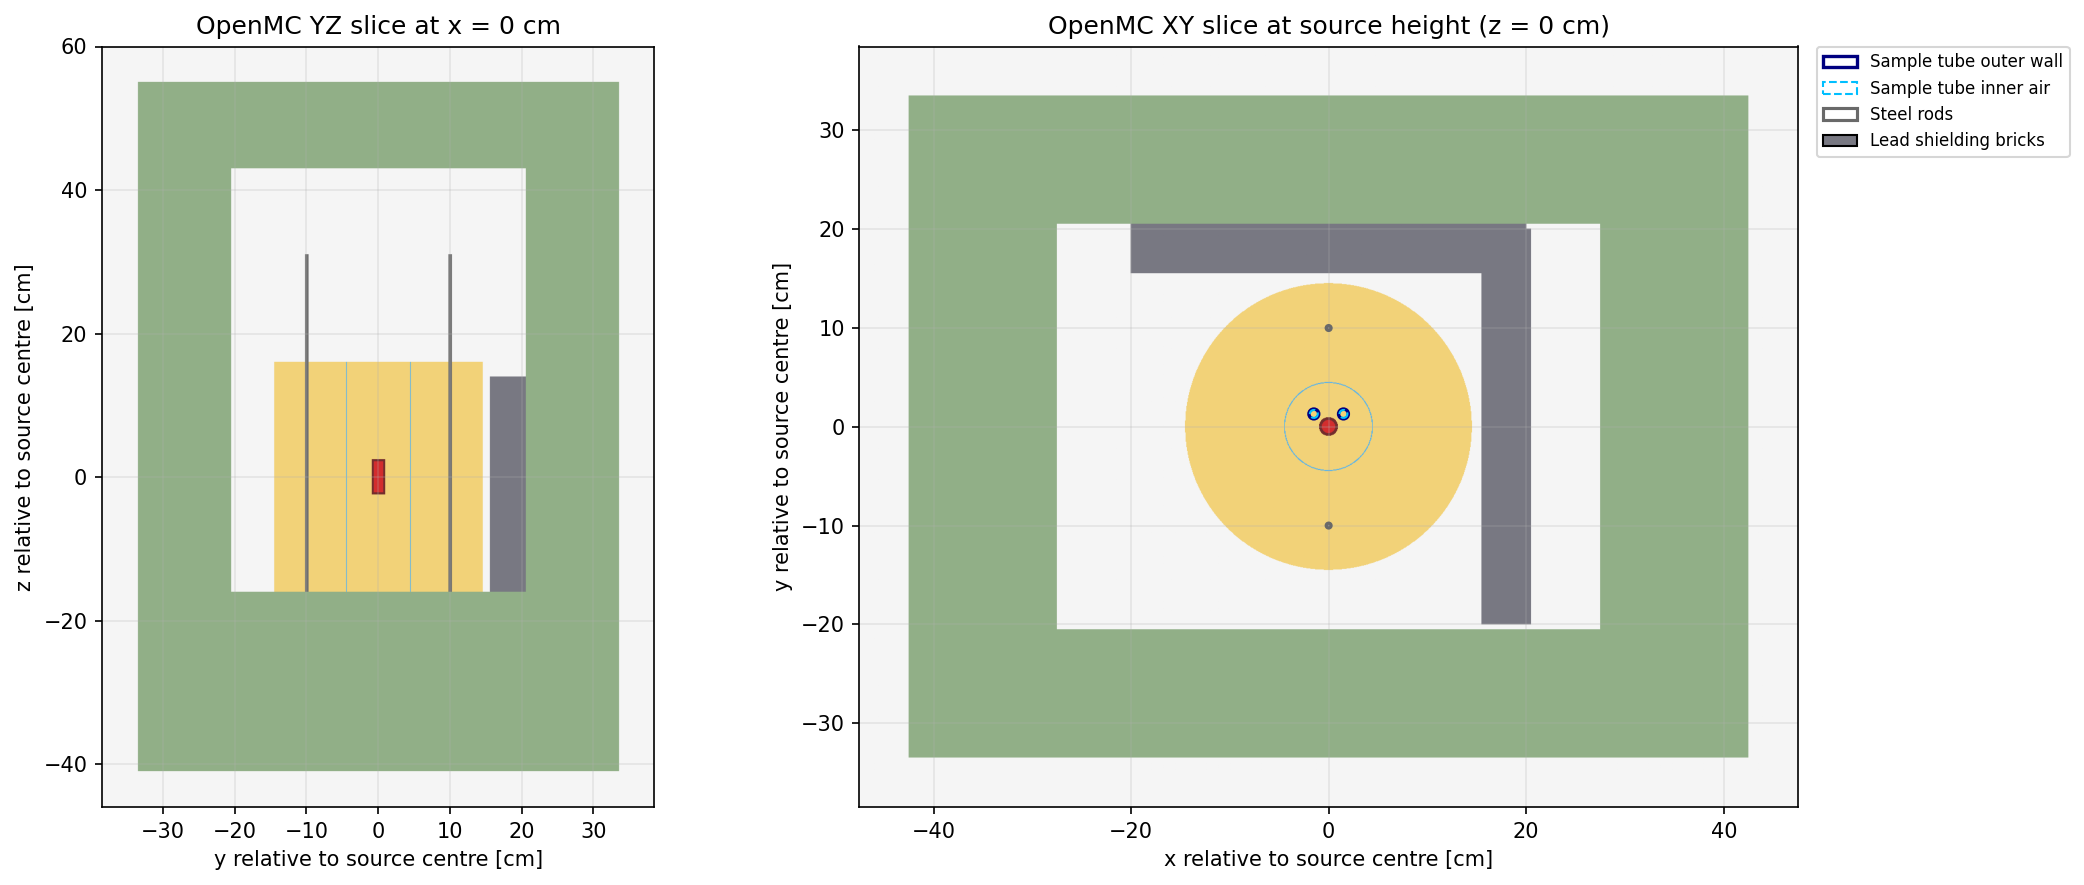

Saved 2D geometry render: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/figures/base_geometry_openmc_2d_slices.png


In [64]:
slice_colors = get_slice_colors()
sample_positions = [(SAMPLE1_X, SAMPLE1_Y), (SAMPLE2_X, SAMPLE2_Y)]
rod_positions = [(ROD1_X, ROD1_Y), (ROD2_X, ROD2_Y)]

fig = plt.figure(figsize=(15, 6), dpi=150)

ax1 = fig.add_subplot(1, 2, 1)
root.plot(basis="yz", origin=(0.0, 0.0, CABINET_ZCENTER), width=(CABINET_Y + 10.0, CABINET_Z + 10.0), pixels=(1400, 1400), axes=ax1, color_by="cell", colors=slice_colors)
ax1.set_title("OpenMC YZ slice at x = 0 cm")
ax1.set_xlabel("y relative to source centre [cm]")
ax1.set_ylabel("z relative to source centre [cm]")
ax1.grid(alpha=0.25)

ax2 = fig.add_subplot(1, 2, 2)
root.plot(basis="xy", origin=(0.0, 0.0, 0.0), width=(CABINET_X + 10.0, CABINET_Y + 10.0), pixels=(1400, 1400), axes=ax2, color_by="cell", colors=slice_colors)
ax2.set_title("OpenMC XY slice at source height (z = 0 cm)")
ax2.set_xlabel("x relative to source centre [cm]")
ax2.set_ylabel("y relative to source centre [cm]")
ax2.grid(alpha=0.25)

for idx, (x0, y0) in enumerate(sample_positions):
    ax2.add_patch(Circle((x0, y0), SAMPLE_TUBE_OUTER_RADIUS, fill=False, edgecolor="navy", linewidth=1.6, zorder=6, label="Sample tube outer wall" if idx == 0 else None))
    ax2.add_patch(Circle((x0, y0), SAMPLE_TUBE_INNER_RADIUS, fill=False, edgecolor="deepskyblue", linewidth=1.0, linestyle="--", zorder=6, label="Sample tube inner air" if idx == 0 else None))

for idx, (x0, y0) in enumerate(rod_positions):
    ax2.add_patch(Circle((x0, y0), ROD_RADIUS, fill=False, edgecolor="dimgray", linewidth=1.5, zorder=6, label="Steel rods" if idx == 0 else None))

handles, labels = ax2.get_legend_handles_labels()
if "lead_brick_cells" in globals():
    handles.append(Patch(facecolor=(120/255, 120/255, 130/255), edgecolor="black", label="Lead shielding bricks"))
ax2.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=True, borderaxespad=0.0)

plt.tight_layout()
geometry_2d_path = FIGURE_DIR / "base_geometry_openmc_2d_slices.png"
fig.savefig(geometry_2d_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved 2D geometry render: {geometry_2d_path}")

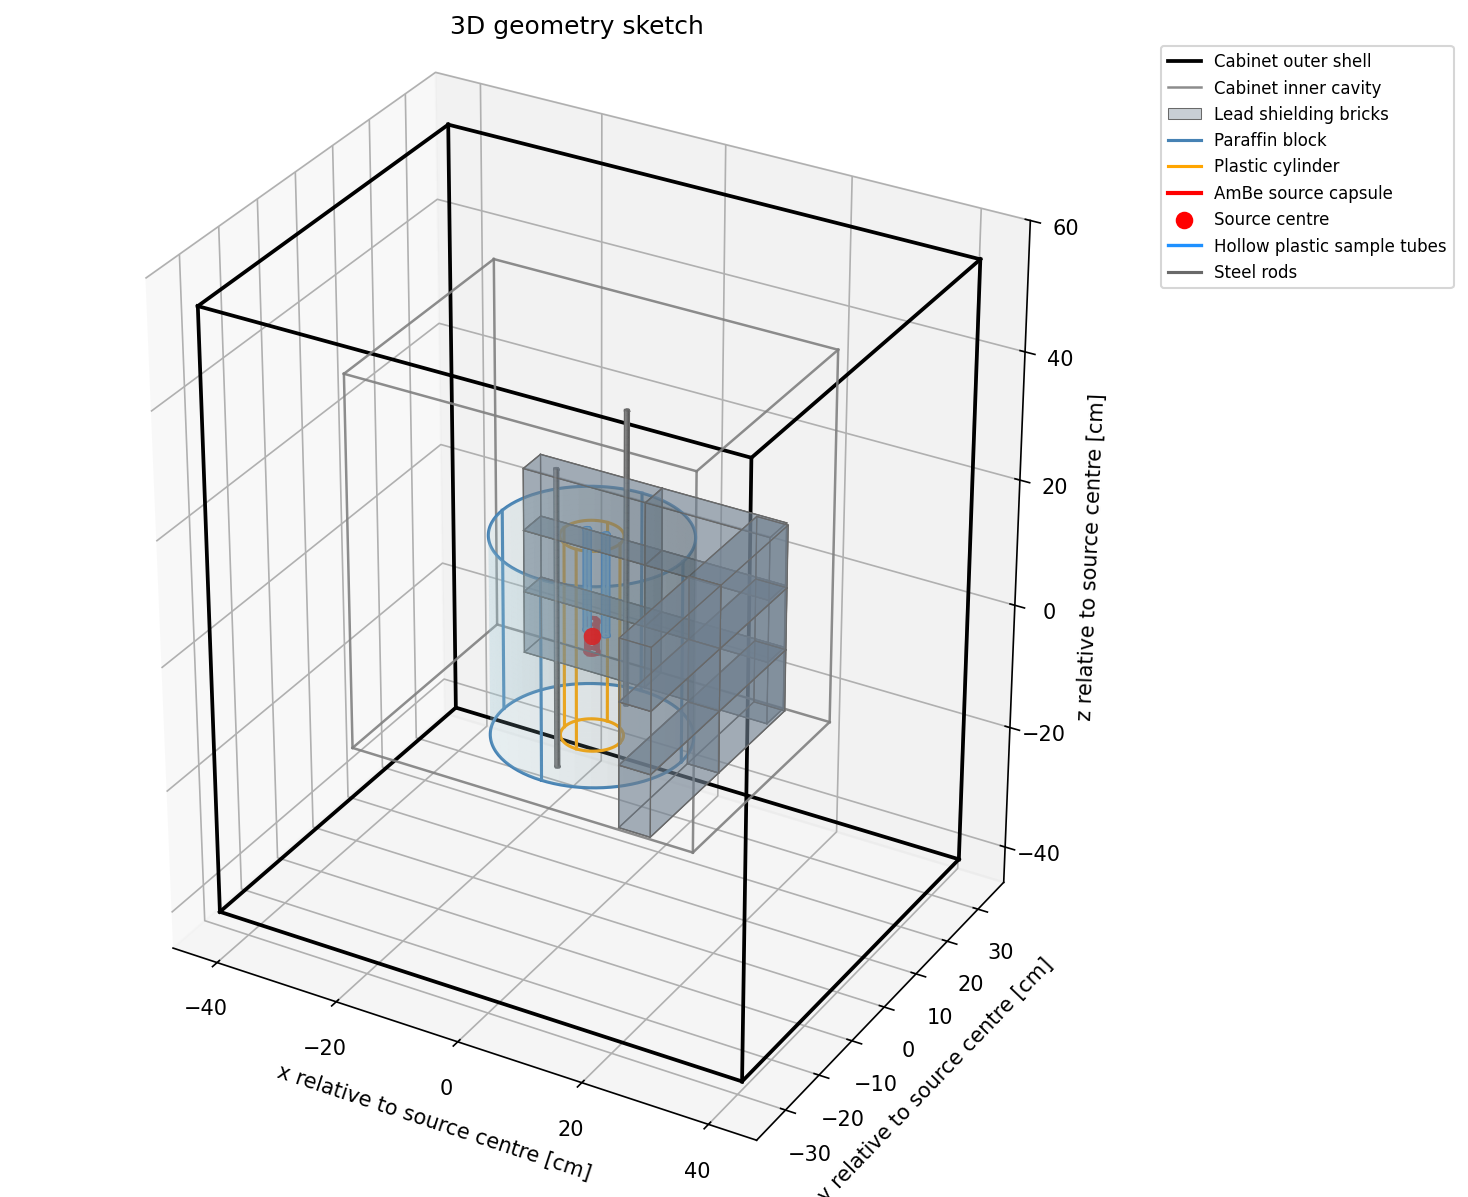

Saved 3D geometry render: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/figures/base_geometry_3d_sketch.png


In [65]:
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection="3d")

draw_box_edges(ax, CABINET_XMIN, CABINET_XMAX, CABINET_YMIN, CABINET_YMAX, CABINET_ZMIN, CABINET_ZMAX, color="black", lw=1.8, label="Cabinet outer shell")
draw_box_edges(ax, CABINET_INNER_XMIN, CABINET_INNER_XMAX, CABINET_INNER_YMIN, CABINET_INNER_YMAX, CABINET_INNER_ZMIN, CABINET_INNER_ZMAX, color="gray", lw=1.2, alpha=0.9, label="Cabinet inner cavity")

if "LEAD_BRICKS" in globals():
    first = True
    for brick in LEAD_BRICKS:
        draw_box_solid(ax, brick["xmin"], brick["xmax"], brick["ymin"], brick["ymax"], brick["zmin"], brick["zmax"], color="slategray", alpha=0.38, edgecolor="dimgray", lw=0.5, label="Lead shielding bricks" if first else None)
        draw_box_edges(ax, brick["xmin"], brick["xmax"], brick["ymin"], brick["ymax"], brick["zmin"], brick["zmax"], color="dimgray", lw=0.7, alpha=0.85)
        first = False

draw_cylinder_surface(ax, PARAFFIN_RADIUS, PARAFFIN_ZMIN, PARAFFIN_ZMAX, color="lightblue", alpha=0.18)
draw_cylinder_wireframe(ax, PARAFFIN_RADIUS, PARAFFIN_ZMIN, PARAFFIN_ZMAX, color="steelblue", lw=1.5, label="Paraffin block")
draw_cylinder_wireframe(ax, PLASTIC_OUTER_RADIUS, PARAFFIN_ZMIN, PARAFFIN_ZMAX, color="orange", lw=1.5, label="Plastic cylinder")
draw_cylinder_wireframe(ax, SOURCE_OUTER_RADIUS, SOURCE_ZMIN, SOURCE_ZMAX, color="red", lw=2.0, label="AmBe source capsule")
ax.scatter([0.0], [0.0], [0.0], color="red", s=55, label="Source centre")

for idx, (x0, y0) in enumerate(sample_positions):
    draw_cylinder_wireframe(ax, SAMPLE_TUBE_OUTER_RADIUS, SAMPLE_TUBE_ZMIN, SAMPLE_TUBE_ZMAX, x0=x0, y0=y0, color="dodgerblue", lw=1.6, label="Hollow plastic sample tubes" if idx == 0 else None)
    draw_cylinder_wireframe(ax, SAMPLE_TUBE_INNER_RADIUS, SAMPLE_TUBE_ZMIN, SAMPLE_TUBE_ZMAX, x0=x0, y0=y0, color="lightskyblue", lw=0.9, alpha=0.85)

for idx, (x0, y0) in enumerate(rod_positions):
    draw_cylinder_surface(ax, ROD_RADIUS, ROD_ZMIN, ROD_ZMAX, x0=x0, y0=y0, color="lightgray", alpha=0.25)
    draw_cylinder_wireframe(ax, ROD_RADIUS, ROD_ZMIN, ROD_ZMAX, x0=x0, y0=y0, color="dimgray", lw=1.5, label="Steel rods" if idx == 0 else None)

pad = 5.0
ax.set_xlim(CABINET_XMIN - pad, CABINET_XMAX + pad)
ax.set_ylim(CABINET_YMIN - pad, CABINET_YMAX + pad)
ax.set_zlim(CABINET_ZMIN - pad, CABINET_ZMAX + pad)
ax.set_xlabel("x relative to source centre [cm]")
ax.set_ylabel("y relative to source centre [cm]")
ax.set_zlabel("z relative to source centre [cm]")
ax.set_title("3D geometry sketch")
ax.set_box_aspect((CABINET_X, CABINET_Y, CABINET_Z))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=True, borderaxespad=0.0)

plt.tight_layout()
geometry_3d_path = FIGURE_DIR / "base_geometry_3d_sketch.png"
fig.savefig(geometry_3d_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved 3D geometry render: {geometry_3d_path}")

## 5) Source, settings and base tallies

This section builds the neutron fixed-source model with the same base tally positions used later as reference points. It does not run OpenMC; it only creates and exports the model input files.

In [66]:
model_data = ambe_base_model.build_base_neutron_model(
    batches=120,
    particles=50_000,
    export_xml=True,
    verbose=True,
)

base_neutron_model = model_data["model"]
base_neutron_settings = model_data["settings"]
base_neutron_tallies = model_data["tallies"]
P_TALLY_POINTS = model_data["P_TALLY_POINTS"]

print("Base neutron model and tallies created.")
print(f"Number of tallies: {len(base_neutron_tallies)}")

Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           = 0.955 cm
  Source active radius          = 0.675 cm
  Source active height          = 4.300 cm

Materials and geometry built.
Defined cells:
  195: Cabinet wall
  196: Cabinet inner air
  197: Inner paraffin block around source
  198: Outer paraffin moderator
  199: 

In [67]:
tally_position_rows = []
for point_name, center in P_TALLY_POINTS.items():
    x, y, z = center
    position = point_name.split("_")[0]
    tally_position_rows.append({
        "point_name": point_name,
        "position": position,
        "x_cm": x,
        "y_cm": y,
        "z_cm": z,
    })

tally_position_df = pd.DataFrame(tally_position_rows)
tally_position_path = TABLE_DIR / "base_tally_positions.csv"
tally_position_df.to_csv(tally_position_path, index=False)

print("Saved base tally-position table.")
print(tally_position_path)
display(tally_position_df)

Saved base tally-position table.
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/base_tally_positions.csv


,point_name,position,x_cm,y_cm,z_cm
0,P1_h42,P1,0.000000,-34.500000,1.0
1,P1_h85,P1,0.000000,-34.500000,44.0
2,P2_h55,P2,43.207107,-34.207107,14.0
3,P2_h85,P2,43.207107,-34.207107,44.0
4,P3_h45,P3,43.500000,0.000000,4.0
5,P3_h85,P3,43.500000,0.000000,44.0
6,P4_h42,P4,43.207107,34.207107,1.0
7,P4_h113,P4,43.207107,34.207107,72.0
8,P5_h45,P5,0.000000,34.500000,4.0
9,P5_h85,P5,0.000000,34.500000,44.0


## 6) Geometry render including base tally points

This render is used to verify that the theoretical tally points are located consistently with the shared geometry. Later notebooks use more measurement-specific points, but these base points define the common P1--P5 convention.

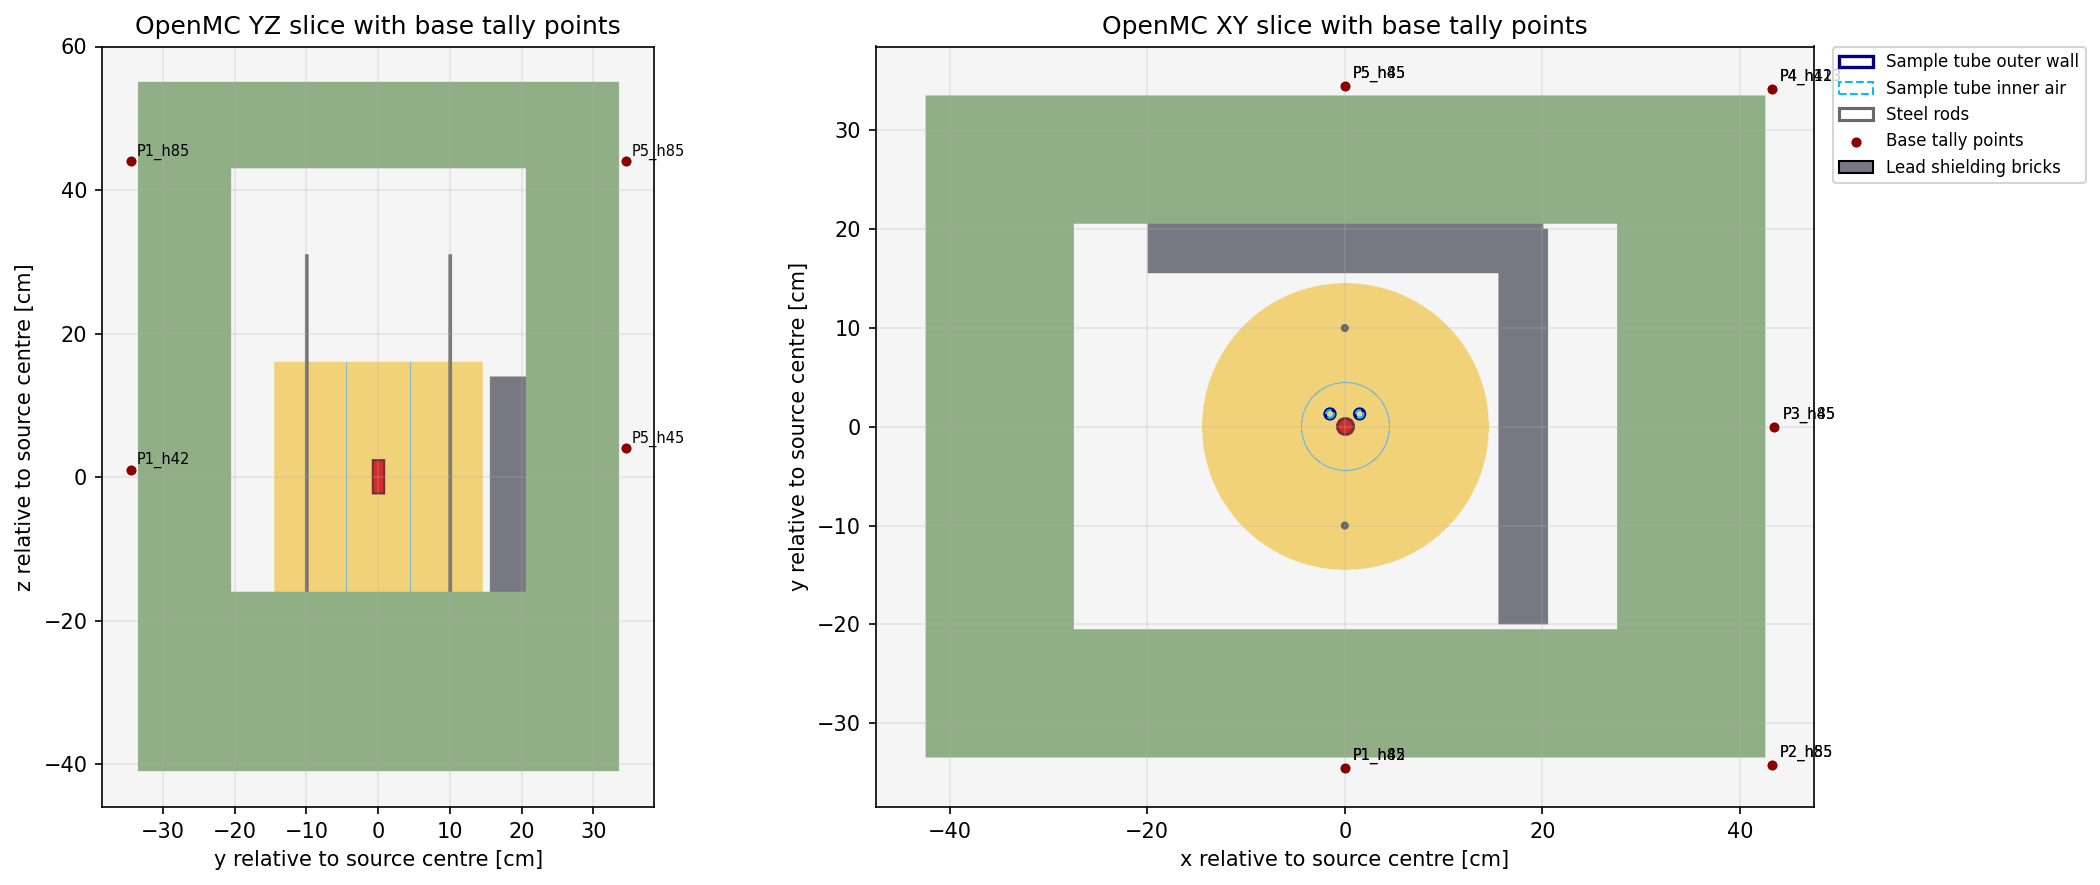

Saved 2D geometry-with-tallies render: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/figures/base_geometry_openmc_2d_slices_with_tallies.png


In [68]:
fig = plt.figure(figsize=(15, 6), dpi=150)

ax1 = fig.add_subplot(1, 2, 1)
root.plot(basis="yz", origin=(0.0, 0.0, CABINET_ZCENTER), width=(CABINET_Y + 10.0, CABINET_Z + 10.0), pixels=(1400, 1400), axes=ax1, color_by="cell", colors=slice_colors)
ax1.set_title("OpenMC YZ slice with base tally points")
ax1.set_xlabel("y relative to source centre [cm]")
ax1.set_ylabel("z relative to source centre [cm]")
ax1.grid(alpha=0.25)

first = True
for name, (x, y, z) in P_TALLY_POINTS.items():
    if abs(x) <= 0.75:
        ax1.scatter(y, z, s=30, color="darkred", edgecolor="white", linewidth=0.6, zorder=5, label="Tally points in YZ slice" if first else None)
        ax1.text(y + 0.8, z + 0.8, name, fontsize=7, color="black")
        first = False

ax2 = fig.add_subplot(1, 2, 2)
root.plot(basis="xy", origin=(0.0, 0.0, 0.0), width=(CABINET_X + 10.0, CABINET_Y + 10.0), pixels=(1400, 1400), axes=ax2, color_by="cell", colors=slice_colors)
ax2.set_title("OpenMC XY slice with base tally points")
ax2.set_xlabel("x relative to source centre [cm]")
ax2.set_ylabel("y relative to source centre [cm]")
ax2.grid(alpha=0.25)

for idx, (x0, y0) in enumerate(sample_positions):
    ax2.add_patch(Circle((x0, y0), SAMPLE_TUBE_OUTER_RADIUS, fill=False, edgecolor="navy", linewidth=1.6, zorder=6, label="Sample tube outer wall" if idx == 0 else None))
    ax2.add_patch(Circle((x0, y0), SAMPLE_TUBE_INNER_RADIUS, fill=False, edgecolor="deepskyblue", linewidth=1.0, linestyle="--", zorder=6, label="Sample tube inner air" if idx == 0 else None))

for idx, (x0, y0) in enumerate(rod_positions):
    ax2.add_patch(Circle((x0, y0), ROD_RADIUS, fill=False, edgecolor="dimgray", linewidth=1.5, zorder=6, label="Steel rods" if idx == 0 else None))

first = True
for name, (x, y, z) in P_TALLY_POINTS.items():
    ax2.scatter(x, y, s=30, color="darkred", edgecolor="white", linewidth=0.6, zorder=7, label="Base tally points" if first else None)
    ax2.text(x + 0.8, y + 0.8, name, fontsize=7, color="black")
    first = False

handles, labels = ax2.get_legend_handles_labels()
if "lead_brick_cells" in globals():
    handles.append(Patch(facecolor=(120/255, 120/255, 130/255), edgecolor="black", label="Lead shielding bricks"))
ax2.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=True, borderaxespad=0.0)

plt.tight_layout()
geometry_tally_2d_path = FIGURE_DIR / "base_geometry_openmc_2d_slices_with_tallies.png"
fig.savefig(geometry_tally_2d_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved 2D geometry-with-tallies render: {geometry_tally_2d_path}")

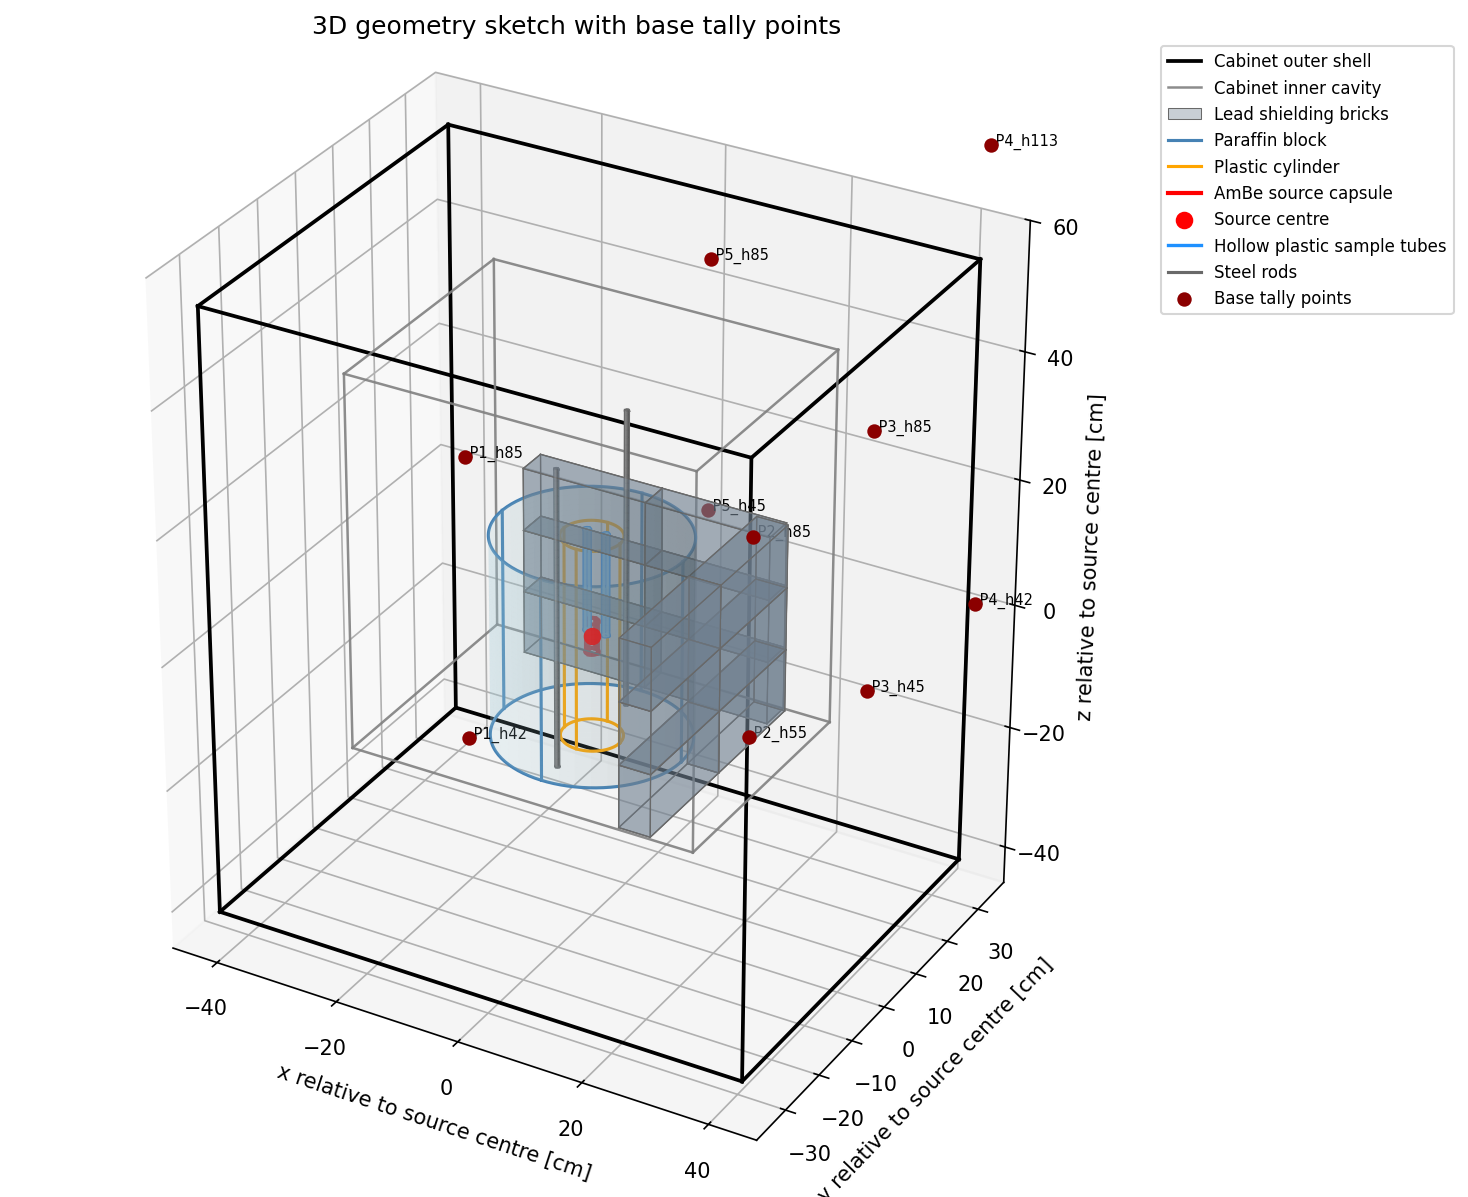

Saved 3D geometry-with-tallies render: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/figures/base_geometry_3d_sketch_with_tallies.png


In [69]:
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection="3d")

draw_box_edges(ax, CABINET_XMIN, CABINET_XMAX, CABINET_YMIN, CABINET_YMAX, CABINET_ZMIN, CABINET_ZMAX, color="black", lw=1.8, label="Cabinet outer shell")
draw_box_edges(ax, CABINET_INNER_XMIN, CABINET_INNER_XMAX, CABINET_INNER_YMIN, CABINET_INNER_YMAX, CABINET_INNER_ZMIN, CABINET_INNER_ZMAX, color="gray", lw=1.2, alpha=0.9, label="Cabinet inner cavity")

if "LEAD_BRICKS" in globals():
    first = True
    for brick in LEAD_BRICKS:
        draw_box_solid(ax, brick["xmin"], brick["xmax"], brick["ymin"], brick["ymax"], brick["zmin"], brick["zmax"], color="slategray", alpha=0.38, edgecolor="dimgray", lw=0.5, label="Lead shielding bricks" if first else None)
        draw_box_edges(ax, brick["xmin"], brick["xmax"], brick["ymin"], brick["ymax"], brick["zmin"], brick["zmax"], color="dimgray", lw=0.7, alpha=0.85)
        first = False

draw_cylinder_surface(ax, PARAFFIN_RADIUS, PARAFFIN_ZMIN, PARAFFIN_ZMAX, color="lightblue", alpha=0.18)
draw_cylinder_wireframe(ax, PARAFFIN_RADIUS, PARAFFIN_ZMIN, PARAFFIN_ZMAX, color="steelblue", lw=1.5, label="Paraffin block")
draw_cylinder_wireframe(ax, PLASTIC_OUTER_RADIUS, PARAFFIN_ZMIN, PARAFFIN_ZMAX, color="orange", lw=1.5, label="Plastic cylinder")
draw_cylinder_wireframe(ax, SOURCE_OUTER_RADIUS, SOURCE_ZMIN, SOURCE_ZMAX, color="red", lw=2.0, label="AmBe source capsule")
ax.scatter([0.0], [0.0], [0.0], color="red", s=55, label="Source centre")

for idx, (x0, y0) in enumerate(sample_positions):
    draw_cylinder_wireframe(ax, SAMPLE_TUBE_OUTER_RADIUS, SAMPLE_TUBE_ZMIN, SAMPLE_TUBE_ZMAX, x0=x0, y0=y0, color="dodgerblue", lw=1.6, label="Hollow plastic sample tubes" if idx == 0 else None)
    draw_cylinder_wireframe(ax, SAMPLE_TUBE_INNER_RADIUS, SAMPLE_TUBE_ZMIN, SAMPLE_TUBE_ZMAX, x0=x0, y0=y0, color="lightskyblue", lw=0.9, alpha=0.85)

for idx, (x0, y0) in enumerate(rod_positions):
    draw_cylinder_surface(ax, ROD_RADIUS, ROD_ZMIN, ROD_ZMAX, x0=x0, y0=y0, color="lightgray", alpha=0.25)
    draw_cylinder_wireframe(ax, ROD_RADIUS, ROD_ZMIN, ROD_ZMAX, x0=x0, y0=y0, color="dimgray", lw=1.5, label="Steel rods" if idx == 0 else None)

first = True
for name, (x, y, z) in P_TALLY_POINTS.items():
    ax.scatter([x], [y], [z], color="darkred", s=35, label="Base tally points" if first else None)
    ax.text(x, y, z, f" {name}", fontsize=7)
    first = False

pad = 5.0
ax.set_xlim(CABINET_XMIN - pad, CABINET_XMAX + pad)
ax.set_ylim(CABINET_YMIN - pad, CABINET_YMAX + pad)
ax.set_zlim(CABINET_ZMIN - pad, CABINET_ZMAX + pad)
ax.set_xlabel("x relative to source centre [cm]")
ax.set_ylabel("y relative to source centre [cm]")
ax.set_zlabel("z relative to source centre [cm]")
ax.set_title("3D geometry sketch with base tally points")
ax.set_box_aspect((CABINET_X, CABINET_Y, CABINET_Z))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=True, borderaxespad=0.0)

plt.tight_layout()
geometry_tally_3d_path = FIGURE_DIR / "base_geometry_3d_sketch_with_tallies.png"
fig.savefig(geometry_tally_3d_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved 3D geometry-with-tallies render: {geometry_tally_3d_path}")

## 7) Final output summary and save

This section collects output paths and short interpretation notes so Notebook 1 has the same traceability style as the later notebooks.

In [70]:
output_inventory_rows = []

for path in sorted(TABLE_DIR.glob("*.csv")):
    output_inventory_rows.append({"type": "table", "path": str(path.relative_to(BASE_DIR))})

for path in sorted(FIGURE_DIR.glob("*.png")):
    output_inventory_rows.append({"type": "figure", "path": str(path.relative_to(BASE_DIR))})

output_inventory_df = pd.DataFrame(output_inventory_rows)
output_inventory_path = OUTPUT_DIR / "base_model_output_inventory.csv"
output_inventory_df.to_csv(output_inventory_path, index=False)

metadata_rows = [
    {"quantity": "Notebook purpose", "value": "Build and document the shared base OpenMC geometry, materials, source model and base tally positions."},
    {"quantity": "Shared geometry source", "value": "ambe_base_model.py"},
    {"quantity": "Main neutron source strength", "value": f"{SOURCE_NEUTRON_EMISSION:.6e} n/s"},
    {"quantity": "Estimated gamma/neutron ratio", "value": f"{gamma_per_neutron_ratio:.6e} photons/neutron" if np.isfinite(gamma_per_neutron_ratio) else "not available"},
    {"quantity": "Estimated gamma source strength", "value": f"{source_gamma_emission:.6e} photons/s" if np.isfinite(source_gamma_emission) else "not available"},
    {"quantity": "Cabinet outer dimensions", "value": f"{CABINET_X:.1f} x {CABINET_Y:.1f} x {CABINET_Z:.1f} cm"},
    {"quantity": "Cabinet z range", "value": f"{CABINET_ZMIN:.1f} to {CABINET_ZMAX:.1f} cm"},
    {"quantity": "Paraffin dimensions", "value": f"diameter {2*PARAFFIN_RADIUS:.1f} cm, height {PARAFFIN_HEIGHT:.1f} cm"},
    {"quantity": "Lead shielding bricks", "value": f"{len(lead_brick_cells) if 'lead_brick_cells' in globals() else 'not available'} bricks"},
    {"quantity": "Base tally points", "value": f"{len(P_TALLY_POINTS)} P1--P5 reference points"},
]

base_model_metadata_df = pd.DataFrame(metadata_rows)
metadata_path = TABLE_DIR / "base_model_metadata.csv"
base_model_metadata_df.to_csv(metadata_path, index=False)

print("Final Notebook 1 outputs saved.")
print(f"Inventory: {output_inventory_path}")
print(f"Metadata:  {metadata_path}")
print()
print("Output inventory:")
display(output_inventory_df)
print()
print("Base model metadata:")
display(base_model_metadata_df)

Final Notebook 1 outputs saved.
Inventory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/base_model_output_inventory.csv
Metadata:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/base_model_outputs/tables/base_model_metadata.csv

Output inventory:


,type,path
0,table,base_model_outputs/tables/ambe_gamma_lines.csv
1,table,base_model_outputs/tables/base_geometry_summary.csv
2,table,base_model_outputs/tables/base_material_summary.csv
3,table,base_model_outputs/tables/base_model_metadata.csv
4,table,base_model_outputs/tables/base_tally_positions.csv
5,table,base_model_outputs/tables/lead_brick_geometry.csv
6,table,base_model_outputs/tables/source_scaling_summary.csv
7,figure,base_model_outputs/figures/ambe_gamma_emission_lines.png
8,figure,base_model_outputs/figures/ambe_neutron_emission_spectrum.png
9,figure,base_model_outputs/figures/base_geometry_3d_sketch.png



Base model metadata:


,quantity,value
0,Notebook purpose,"Build and document the shared base OpenMC geometry, materials, source model and base tally positions."
1,Shared geometry source,ambe_base_model.py
2,Main neutron source strength,1.200000e+07 n/s
3,Estimated gamma/neutron ratio,6.521014e-01 photons/neutron
4,Estimated gamma source strength,7.825217e+06 photons/s
5,Cabinet outer dimensions,85.0 x 67.0 x 96.0 cm
6,Cabinet z range,-41.0 to 55.0 cm
7,Paraffin dimensions,"diameter 29.0 cm, height 32.0 cm"
8,Lead shielding bricks,12 bricks
9,Base tally points,10 P1--P5 reference points


## 8) Summary and comments

This cleaned Notebook 1 defines the common base model used by the later notebooks.

The central point is that the physical geometry is **not duplicated in the notebook**. The notebook imports the geometry and source-model definitions from `ambe_base_model.py`, and the notebook cells only build, render, test and save outputs from that shared source.

Main comments:

- The Am-Be neutron source is represented by an isotropic fixed-source neutron distribution with a broad ALPHANSO-based neutron energy spectrum.
- The prompt gamma source is represented by discrete ALPHANSO gamma lines. The source is strongly dominated by the line near $4.4389\,\mathrm{MeV}$.
- The source centre is defined as $(x,y,z)=(0,0,0)$.
- The paraffin block is centred around the source in $z$, while the cabinet is not centred around the source vertically because the paraffin sits on the inner bottom of the cabinet.
- The saved geometry renders document the cabinet, paraffin, source capsule, sample tubes, rods and lead-brick placement.
- The base tally points are only reference tally positions. Later notebooks use measurement-specific point lists for the detailed neutron and gamma comparisons.

The outputs from this notebook are stored in:

`base_model_outputs/`